2) Data Wrangling II

Create an “Academic performance” dataset of students and perform the following operations using Python.

1. Scan all variables for missing values and inconsistencies. If there are missing values and/or inconsistencies, use any of the suitable techniques to deal with them.
2. Scan all numeric variables for outliers. If there are outliers, use any of the suitable techniques to deal with them.
3. Apply data transformations on at least one of the variables. The purpose of this transformation should be one of the following reasons: to change the scale for better understanding of the variable, to convert a non-linear relation into a linear one, or to decrease the skewness and convert the distribution into a normal distribution.
Reason and document your approach properly.

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# 1. Create a simple Academic Performance dataset
data = {
    'Student_ID': [1, 2, 3, 4, 5, 6, 7],
    'Math_Score': [88, 92, np.nan, 45, 67, 999, 75],
    'English_Score': [78, 85, 79, np.nan, 65, 72, 81],
    'Science_Score': [90, 95, 89, 200, 70, 80, np.nan]
}


In [6]:
df = pd.DataFrame(data)
print("Original Dataset:")
print(df)

Original Dataset:
   Student_ID  Math_Score  English_Score  Science_Score
0           1        88.0           78.0           90.0
1           2        92.0           85.0           95.0
2           3         NaN           79.0           89.0
3           4        45.0            NaN          200.0
4           5        67.0           65.0           70.0
5           6       999.0           72.0           80.0
6           7        75.0           81.0            NaN


In [17]:
# 2. Scan for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
Student_ID       0
Math_Score       1
English_Score    1
Science_Score    1
dtype: int64


In [ ]:
# Handle missing values by replacing them with the column mean
df['Math_Score'].fillna(df['Math_Score'].mean(), inplace=True)
df['English_Score'].fillna(df['English_Score'].mean(), inplace=True)
df['Science_Score'].fillna(df['Science_Score'].mean(), inplace=True)



C:\Users\Anil Abhange\AppData\Local\Temp\ipykernel_1556\769821948.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Math_Score'].fillna(df['Math_Score'].mean(), inplace=True)
C:\Users\Anil Abhange\AppData\Local\Temp\ipykernel_1556\769821948.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

In [19]:
print("\nDataset after handling missing values:")
print(df)



Dataset after handling missing values:
   Student_ID  Math_Score  English_Score  Science_Score
0           1   88.000000      78.000000           90.0
1           2   92.000000      85.000000           95.0
2           3  227.666667      79.000000           89.0
3           4   45.000000      76.666667          200.0
4           5   67.000000      65.000000           70.0
5           6  999.000000      72.000000           80.0
6           7   75.000000      81.000000          104.0


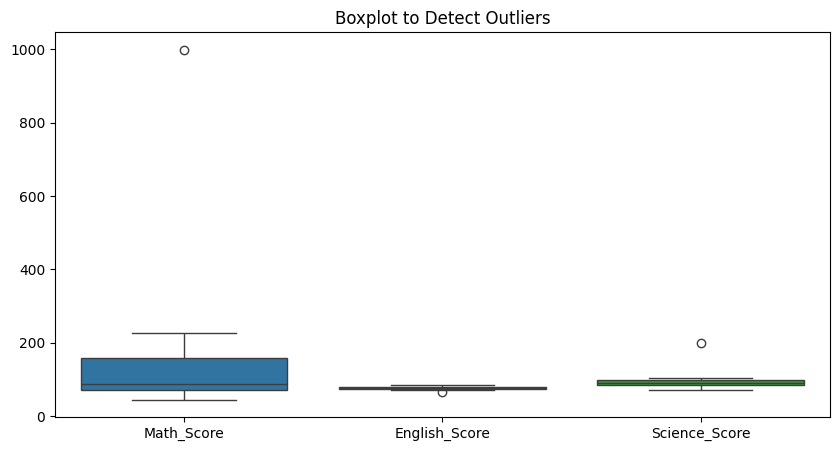

In [ ]:
# 3. Scan numeric variables for inconsistencies/outliers

# Visual check using boxplots
plt.figure(figsize=(10, 5))  
sns.boxplot(data=df[['Math_Score', 'English_Score', 'Science_Score']])
plt.title("Boxplot to Detect Outliers")
plt.show()


In [21]:
# We can see 999 and 200 are outliers.
# Handle outliers by capping (Winsorization)
# For Math_Score
df['Math_Score'] = np.where(df['Math_Score'] > 100, 100, df['Math_Score'])

# For Science_Score
df['Science_Score'] = np.where(df['Science_Score'] > 100, 100, df['Science_Score'])

print("\nDataset after handling outliers:")
print(df)


Dataset after handling outliers:
   Student_ID  Math_Score  English_Score  Science_Score
0           1        88.0      78.000000           90.0
1           2        92.0      85.000000           95.0
2           3       100.0      79.000000           89.0
3           4        45.0      76.666667          100.0
4           5        67.0      65.000000           70.0
5           6       100.0      72.000000           80.0
6           7        75.0      81.000000          100.0


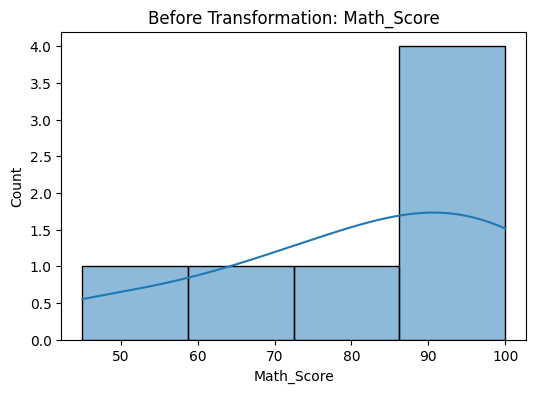

In [22]:
# 4. Data Transformation
# Let's apply a log transformation to 'Math_Score' to reduce skewness

# Before Transformation
plt.figure(figsize=(6, 4))
sns.histplot(df['Math_Score'], kde=True)
plt.title("Before Transformation: Math_Score")
plt.show()

In [23]:
# Apply log transformation
df['Math_Score_Log'] = np.log(df['Math_Score'])


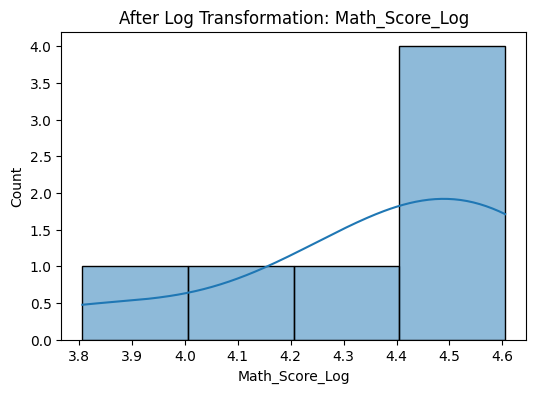

In [24]:
# After Transformation
plt.figure(figsize=(6, 4))
sns.histplot(df['Math_Score_Log'], kde=True)
plt.title("After Log Transformation: Math_Score_Log")
plt.show()

In [25]:
print("\nDataset after transformation:")
print(df)



Dataset after transformation:
   Student_ID  Math_Score  English_Score  Science_Score  Math_Score_Log
0           1        88.0      78.000000           90.0        4.477337
1           2        92.0      85.000000           95.0        4.521789
2           3       100.0      79.000000           89.0        4.605170
3           4        45.0      76.666667          100.0        3.806662
4           5        67.0      65.000000           70.0        4.204693
5           6       100.0      72.000000           80.0        4.605170
6           7        75.0      81.000000          100.0        4.317488


In [26]:
# 5. Documentation:
'''
- Missing values were filled with the mean value because it preserves the overall distribution.
- Outliers (like 999 and 200) were capped to 100 because typical academic scores are between 0-100.
- Log transformation was applied to 'Math_Score' to reduce skewness and make the distribution closer to normal.
'''

"\n- Missing values were filled with the mean value because it preserves the overall distribution.\n- Outliers (like 999 and 200) were capped to 100 because typical academic scores are between 0-100.\n- Log transformation was applied to 'Math_Score' to reduce skewness and make the distribution closer to normal.\n"